# Momentum Tail-Risk Monitor — Final MVP Demo

## Executive summary

> **Is this customizable momentum book becoming fragile, how does that compare with published UMD context, and what deterministic evidence supports the judgment?**

The default book is an S&P 500 12-1 long-10 / short-10 portfolio — a stand-in for a PM’s own customized momentum holdings. Ken French UMD / Daniel–Moskowitz state is shown only as a comparison benchmark. Quantitative methods measure and monitor risk; AI organizes timestamped evidence without replacing deterministic controls or human judgment.

## 1. Problem definition

The monitor tracks conditions associated with US equity **momentum crashes** on a PM-facing book: macro recovery after drawdowns, long/short beta divergence, portfolio drawdown, short-leg losses, unwind structure, and crowding proxies (concentration / breadth / correlated-theme unwind).

- **Primary object:** S&P 500 12-1 long-10 / short-10 as the default **customizable PM momentum portfolio**.
- **Comparison benchmark:** Ken French UMD / Daniel–Moskowitz market state.

It is decision support — not a trading signal or causal forecast.

## 2. System architecture

```text
MVPConfig (as-of date, comparison, thresholds)
  → run_mvp()
       → UMD / DM comparison benchmark
       → PM momentum portfolio scorecard (S&P 10/10 default customization)
       → six-row unwind monitor + three mechanism scenarios
       → Crowding panel (T0 proxies + optional T1 FINRA/GDELT side notes)
       → exact-date evidence replay
       → optional constrained interpretation
  → presentation layer (charts + PM card)
```


In [1]:
# Bootstrap imports whether the kernel starts in the repository root or notebooks/.
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

from src.mvp.config import MVPConfig, default_demo_config
from src.mvp.pipeline import run_mvp
from src.mvp.presentation import (
    build_comparison_html,
    build_crowding_panel_html,
    build_macro_component_html,
    build_unwind_summary_html,
    plot_trailing_risk_chart,
    render_pm_card_html,
    save_pm_outputs,
)

INJECTED_INTERPRETER = globals().get("INJECTED_INTERPRETER")

In [2]:
# ============================================================
# DEMO PARAMETERS — EDIT THESE, THEN RUN ALL
# ============================================================
CONFIG = MVPConfig(
    as_of_date="2024-01-05",
    compare_to_date="2023-12-01",
    threshold_profile="default",
    horizon_days=20,
    use_llm=False,
)
# CONFIG = default_demo_config()  # equivalent to the settings above

## 3. Run the unified MVP pipeline

In [3]:
result = run_mvp(CONFIG, interpreter=INJECTED_INTERPRETER)
card = result.deterministic_input
interpretation = result.interpretation
unwind = result.unwind
signals = card.triggered_quant_signals + card.non_triggered_relevant_signals
evidence_quality = card.audit_metadata.get("evidence_quality", "unavailable")
print(
    f"Ready — {card.as_of_date} | UMD comparison={card.overall_risk_state} | "
    f"triggers={len(card.triggered_quant_signals)} | evidence={len(card.retrieved_evidence)} | "
    f"mechanisms={','.join(unwind.active_scenarios) or 'none'} | "
    f"LLM requested/effective={CONFIG.use_llm}/{interpretation.use_llm} | "
    f"run={card.run_id} | fingerprint={result.full_run_fingerprint}"
)
for warning in interpretation.warnings:
    print(f"WARNING — {warning}")

Ready — 2024-01-05 | UMD state=bear_low_volatility | triggers=0 | evidence=7 | mechanisms=none | LLM requested/effective=False/False | run=53c34aa57bb437fc | fingerprint=750f22225b7d9592


## 4. Data sources and point-in-time discipline

- Market/risk windows end on or before the as-of date.
- Portfolio formation, effective month, and observation dates are separate fields.
- Theme cluster membership stops at `t-1`.
- Evidence replays an exact-date validated cache; no live retrieval in the default demo.
- UMD comparison statistics and the PM portfolio book remain separately labeled.

In [4]:
metadata_table = pd.DataFrame(
    [
        ("As-of date", card.as_of_date),
        ("Comparison date", card.comparison_date or "None"),
        ("Threshold profile (Phase 4 scorecard only)", card.threshold_profile),
        ("UMD comparison label", result.display_labels["header_state_label"]),
        ("PM portfolio scorecard label", result.display_labels["scorecard_label"]),
        ("Data cutoff", card.data_cutoff),
        ("Evidence quality", evidence_quality),
        ("LLM requested / effective", f"{CONFIG.use_llm} / {interpretation.use_llm}"),
        ("Card run ID", card.run_id),
        ("Full run fingerprint", result.full_run_fingerprint),
    ],
    columns=["Field", "Value"],
)
display(HTML(metadata_table.to_html(index=False, border=0, escape=True)))

Field,Value
As-of date,2024-01-05
Comparison date,2023-12-01
Threshold profile (Phase 4 scorecard only),default
UMD header label,UMD market state (Ken French factor context)
Scorecard label,Named S&P 500 proxy scorecard (12-1 long 10 / short 10)
Data cutoff,2024-01-05T16:00:00-05:00
Evidence quality,available
LLM requested / effective,False / False
Card run ID,53c34aa57bb437fc
Full run fingerprint,750f22225b7d9592


## 5. UMD comparison: macro regime and recovery state

In [5]:
macro_component_html, current_market_drawdown, composite_triggered = build_macro_component_html(
    card, processed_dir=CONFIG.processed_dir
)
display(HTML(macro_component_html))

Component,Current,Gate,Condition
Recent market drawdown,-14.0%,≤ -20.0% within 126d,not met
Recovery from trough,15.0% · trough age 47d,≥ 5.0% and age 1–63d,met
21d realized volatility,11.2%,≥ 18.2% (prior-only 80th percentile),not met


## 6. PM momentum portfolio (S&P 10/10 default) and long/short attribution

In [6]:
portfolio_dates = pd.read_parquet(
    CONFIG.processed_dir / "leg_risk_history.parquet",
    columns=["date", "formation_date", "effective_month"],
)
portfolio_dates["date"] = pd.to_datetime(portfolio_dates["date"])
selected = portfolio_dates.loc[portfolio_dates["date"].eq(pd.Timestamp(card.as_of_date))]
if len(selected) == 1:
    row = selected.iloc[0]
    print(
        f"Active formation {row['formation_date'].date()} · effective month {row['effective_month']}"
    )
holdings = pd.read_parquet(
    CONFIG.processed_dir / "momentum_portfolio_holdings.parquet"
)
holdings["formation_date"] = pd.to_datetime(holdings["formation_date"])
active = holdings.loc[holdings["formation_date"].eq(selected.iloc[0]["formation_date"])]
display(active[["symbol", "leg", "weight"]].sort_values(["leg", "symbol"]).head(20))

Active formation 2023-12-29 · effective month 2024-01


,symbol,leg,weight
1661,APP,long,0.1
1662,COIN,long,0.1
1669,CRWD,long,0.1
1660,CVNA,long,0.1
1667,META,long,0.1
1664,NVDA,long,0.1
1666,PLTR,long,0.1
1663,SMCI,long,0.1
1668,UBER,long,0.1
1665,VRT,long,0.1


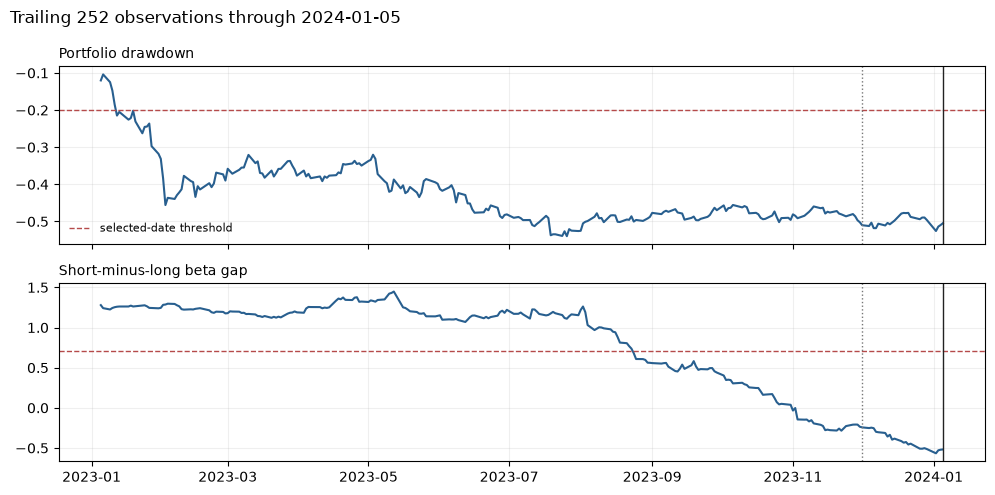

Saved outputs/figures/trailing_risk_2024-01-05.png


In [7]:
fig = plot_trailing_risk_chart(result)
fig_path = ROOT / "outputs" / "figures" / f"trailing_risk_{card.as_of_date}.png"
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path.relative_to(ROOT)}")

## 7. Deterministic four-row scorecard (PM portfolio)

In [8]:
quant_table = pd.DataFrame(
    [
        {
            "Indicator": signal.name.replace("_", " ").title(),
            "Current": signal.current_value,
            "Threshold": signal.threshold,
            "Status": signal.status,
            "Change vs compare": signal.change_vs_comparison,
        }
        for signal in signals
    ]
)
display(HTML(quant_table.to_html(index=False, border=0, escape=True, float_format=lambda x: f"{x:.4f}")))

Indicator,Current,Threshold,Status,Change vs compare
High Volatility Recovery,0.0000,1.0000,not_triggered,0.0000
Short Minus Long Beta Gap,-0.5179,0.7116,not_triggered,-0.2747
Portfolio Drawdown,-0.0903,-0.2000,not_triggered,0.0098
Short Loss In Recovery,0.2039,0.2905,not_triggered,-0.0599


## 8. Momentum crash mechanisms and unwind structure

In [9]:
display(HTML(build_unwind_summary_html(unwind)))

## 8b. Crowding monitor (book-structure proxies)

T0 reuses the unwind spine — portfolio concentration, momentum breadth, and
correlated-theme unwind — as an explicit Crowding panel. Optional T1 side notes
read FINRA loser-leg short-interest z and GDELT crowding attention z.

These are **proxies**, not observed ownership / leverage / flow. They do not
enter mechanism rules or create an aggregate crowding score. Longer-horizon
ideas (PM holdings plug-in, street crowding, financing) live in
`Future_To_DO.md`.


In [ ]:
display(HTML(build_crowding_panel_html(unwind, processed_dir=CONFIG.processed_dir)))


## 9. Timestamped text evidence and interpretation

In [10]:
evidence_table = pd.DataFrame(
    [
        {
            "ID": item.evidence_id,
            "Timestamp": item.timestamp,
            "Source": item.source,
            "Stance": item.stance,
            "Summary": item.headline_or_summary[:120],
        }
        for item in card.retrieved_evidence
    ]
)
display(HTML(evidence_table.to_html(index=False, border=0, escape=True)))
print("\nDeterministic interpretation preview:\n", interpretation.narrative_state)

ID,Timestamp,Source,Stance,Summary
bls-2024-01-05-employment,2024-01-05T08:30:00-05:00,US Bureau of Labor Statistics,supporting,"Employment Situation, December 2023"
bea-2023-12-22-income-outlays,2023-12-22T08:30:00-05:00,US Bureau of Economic Analysis,supporting,"Personal Income and Outlays, November 2023"
bea-2023-12-21-gdp,2023-12-21T08:30:00-05:00,US Bureau of Economic Analysis,supporting,"Gross Domestic Product, Third Estimate, Third Quarter 2023"
reuters-2024-01-05-wall-street,2024-01-05T09:08:00-05:00,Reuters via MarketScreener,contradicting,Wall Street set for weak open after stronger jobs data
fed-2024-01-04-h41,2024-01-04T16:30:00-05:00,Federal Reserve Board,contextual,"Factors Affecting Reserve Balances, January 4, 2024"
bls-2024-01-03-jolts,2024-01-03T10:00:00-05:00,US Bureau of Labor Statistics,contextual,"Job Openings and Labor Turnover, November 2023"
fed-2023-12-13-fomc,2023-12-13T14:00:00-05:00,Federal Reserve Board,contextual,"FOMC statement, December 13, 2023"



Deterministic interpretation preview:
 No implemented fragility condition is currently triggered. This does not rule out risks outside the monitored signal set.


## 10. Validation sanity check (illustrative)

In [11]:
from src.mvp.config import HISTORICAL_EXAMPLE_DATE, REGRESSION_AS_OF_DATE, REGRESSION_COMPARE_TO_DATE

normal_case = run_mvp(MVPConfig(as_of_date=HISTORICAL_EXAMPLE_DATE))
comparison_case = run_mvp(
    MVPConfig(
        as_of_date=REGRESSION_AS_OF_DATE,
        compare_to_date=REGRESSION_COMPARE_TO_DATE,
    )
)

def quantitative_signature(run_result):
    run_signals = run_result.deterministic_input.triggered_quant_signals + run_result.deterministic_input.non_triggered_relevant_signals
    return (
        run_result.deterministic_input.overall_risk_state,
        tuple((s.name, s.current_value, s.threshold, s.status) for s in run_signals),
    )

assert quantitative_signature(normal_case) != quantitative_signature(comparison_case)
print(
    f"PASS — distinct dates produce distinct signatures: "
    f"{HISTORICAL_EXAMPLE_DATE}={normal_case.deterministic_input.overall_risk_state}; "
    f"{REGRESSION_AS_OF_DATE}={comparison_case.deterministic_input.overall_risk_state}."
)

PASS — distinct dates produce distinct signatures: 2026-05-29=normal; 2020-03-24=panic_elevated.


## 11. PM-facing risk output

In [12]:
output_paths = save_pm_outputs(result, output_dir=ROOT / "outputs" / "example_risk_output")
for label, path in output_paths.items():
    print(f"Saved {label}: {path.relative_to(ROOT)}")
display(HTML(render_pm_card_html(result)))

Saved html: outputs/example_risk_output/pm_risk_assessment_2024-01-05.html
Saved md: outputs/example_risk_output/pm_risk_assessment_2024-01-05.md
Saved json: outputs/example_risk_output/pm_risk_assessment_2024-01-05.json


## 12. AI Evidence Layer

> The deterministic system identifies the risk state. Retrieval and DeepSeek are used only to explain the state using contemporaneous public-news evidence.

Optional path after **full or partial** scorecard activation:

`triggered / partial trigger → GDELT retriever (30d, configurable themes, Top 20–50) → DeepSeek short summary + cited evidence`

The LLM does not detect risk, change thresholds, or alter scores.

In [ ]:
from IPython.display import Markdown

from src.evidence.deepseek_explainer import explain_risk_with_deepseek
from src.evidence.gdelt_evidence import (
    DEFAULT_GDELT_THEMES,
    DEFAULT_LOOKBACK_DAYS,
    DEFAULT_MAX_RECORDS,
    DEFAULT_PARTIAL_RATIO,
    TRIGGER_KEYWORDS,
    active_triggers_from_signals,
    classify_trigger_activation,
    load_gdelt_titles,
    no_active_trigger_message,
    no_evidence_message,
    retrieve_gdelt_evidence,
)

# --- Evidence-layer knobs (do not affect deterministic risk detection) ---
EVIDENCE_LOOKBACK_DAYS = DEFAULT_LOOKBACK_DAYS          # recent window
EVIDENCE_MAX_RECORDS = DEFAULT_MAX_RECORDS              # Top 20–50 (default 30)
EVIDENCE_THEMES = list(DEFAULT_GDELT_THEMES)           # panic/rotation/policy/crowding/riskoff
EVIDENCE_INCLUDE_PARTIAL = True                        # activate on near-threshold rows
EVIDENCE_PARTIAL_RATIO = DEFAULT_PARTIAL_RATIO         # e.g. 0.70 of threshold
# Optional: override TRIGGER_KEYWORDS theme terms, or leave None for defaults.
EVIDENCE_TRIGGER_KEYWORDS = None

scorecard_signals = list(card.triggered_quant_signals) + list(
    card.non_triggered_relevant_signals
)
active_triggers = active_triggers_from_signals(
    scorecard_signals,
    include_partial=EVIDENCE_INCLUDE_PARTIAL,
    partial_ratio=EVIDENCE_PARTIAL_RATIO,
)

# A. Active Triggers (deterministic values + evidence-layer activation label)
trigger_rows = []
for signal in scorecard_signals:
    activation = classify_trigger_activation(
        status=signal.status,
        current_value=signal.current_value,
        threshold=signal.threshold,
        direction=signal.direction,
        include_partial=EVIDENCE_INCLUDE_PARTIAL,
        partial_ratio=EVIDENCE_PARTIAL_RATIO,
    )
    trigger_rows.append(
        {
            "Trigger": signal.name,
            "Observed Value": signal.current_value,
            "Threshold": signal.threshold,
            "Scorecard Status": signal.status,
            "Evidence Gate": activation or "inactive",
        }
    )
display(Markdown("### A. Active Triggers"))
display(
    Markdown(
        "_Evidence Gate = `triggered` or `partial` activates retrieval. "
        "Scorecard Status remains the deterministic label and is never rewritten by the LLM._"
    )
)
display(
    HTML(
        pd.DataFrame(trigger_rows).to_html(
            index=False,
            border=0,
            classes="dataframe",
            justify="left",
        )
    )
)
display(
    Markdown(
        f"_Themes in use: `{', '.join(EVIDENCE_THEMES)}` · "
        f"lookback={EVIDENCE_LOOKBACK_DAYS}d · top_n={EVIDENCE_MAX_RECORDS} · "
        f"partial_ratio={EVIDENCE_PARTIAL_RATIO}. "
        f"Keyword map keys: `{', '.join((EVIDENCE_TRIGGER_KEYWORDS or TRIGGER_KEYWORDS).keys())}`._"
    )
)

if not active_triggers:
    display(Markdown(f"*{no_active_trigger_message()}*"))
    gdelt_evidence = pd.DataFrame()
    explanation = {
        "status": "inactive",
        "message": no_active_trigger_message(),
        "trigger_summary": "",
        "recent_narrative": "",
        "momentum_mechanism": "",
        "key_evidence_ids": [],
        "limitations": "",
        "pm_takeaway": "",
    }
else:
    gdelt_titles = load_gdelt_titles()
    gdelt_evidence = retrieve_gdelt_evidence(
        gdelt_titles,
        as_of_date=card.as_of_date,
        active_triggers=active_triggers,
        lookback_days=EVIDENCE_LOOKBACK_DAYS,
        max_records=EVIDENCE_MAX_RECORDS,
        themes=EVIDENCE_THEMES,
        trigger_keywords=EVIDENCE_TRIGGER_KEYWORDS,
    )
    if gdelt_evidence.empty:
        display(Markdown(f"*{no_evidence_message()}*"))
        explanation = {
            "status": "no_evidence",
            "message": no_evidence_message(),
            "trigger_summary": "",
            "recent_narrative": "",
            "momentum_mechanism": "",
            "key_evidence_ids": [],
            "limitations": "",
            "pm_takeaway": "",
        }
    else:
        explanation = explain_risk_with_deepseek(
            active_triggers=active_triggers,
            evidence=gdelt_evidence,
            as_of_date=card.as_of_date,
        )

# B. Retrieved GDELT Evidence
display(Markdown("### B. Retrieved GDELT Evidence"))
if gdelt_evidence.empty:
    display(Markdown("_No GDELT evidence rows to display for this as-of date / window._"))
else:
    evidence_view = gdelt_evidence.head(10)[
        ["evidence_id", "date", "title", "source", "matched_trigger"]
    ].rename(
        columns={
            "evidence_id": "ID",
            "date": "Date",
            "title": "Title or Description",
            "source": "Source",
            "matched_trigger": "Matched Trigger",
        }
    )
    display(
        HTML(
            evidence_view.to_html(
                index=False,
                border=0,
                classes="dataframe",
                justify="left",
            )
        )
    )

# C. DeepSeek Explanation
display(Markdown("### C. DeepSeek Explanation"))
if explanation["status"] == "ok":
    display(
        Markdown(
            "\n".join(
                [
                    f"**Trigger summary.** {explanation['trigger_summary']}",
                    "",
                    f"**Recent narrative.** {explanation['recent_narrative']}",
                    "",
                    f"**Plausible momentum mechanism.** {explanation['momentum_mechanism']}",
                    "",
                    f"**PM takeaway.** {explanation['pm_takeaway']}",
                    "",
                    f"**Limitations.** {explanation['limitations']}",
                    "",
                    f"_Cited evidence IDs: {', '.join(explanation['key_evidence_ids']) or 'none'}_",
                ]
            )
        )
    )
elif explanation["status"] == "llm_unavailable":
    display(Markdown(f"*{explanation['message']}*"))
    display(
        Markdown(
            "Retrieved GDELT rows remain available above; synthesis was skipped."
        )
    )
else:
    display(Markdown(f"*{explanation['message']}*"))

display(
    Markdown(
        "> **Note:** The deterministic system identifies the risk state. "
        "Retrieval and DeepSeek are used only to explain the state using "
        "contemporaneous public-news evidence."
    )
)

## 13. Limitations

- Default PM book uses a survivorship-biased current SPY membership snapshot.
- UMD is a comparison benchmark only; the S&P 10/10 book is the customizable PM portfolio.
- Crowding panel uses book-structure proxies (+ optional FINRA/GDELT side notes); not observed ownership, leverage, or financing.
- Industry classification and live positioning data are unavailable as primary inputs.
- Evidence is cached exact-date replay, not institutional retrieval.
- UMD tail-loss frequency is illustrative comparison context, not the PM book’s forecast.
- Mechanism scenarios are descriptive rules without predictive validation.
- The optional GDELT / DeepSeek layer explains active triggers only; it does not change scores.

## 14. Production path

Longer-horizon PM imagination (T2 holdings plug-in, T3 street crowding, T4
leverage / financing / flow, ops, OOS) is tracked in **`Future_To_DO.md`**.

Short list retained here:

- Plug-in interface for a PM’s own customized momentum holdings.
- Point-in-time membership and sector history.
- Observed holdings, leverage, flow, and street crowding overlays.
- Daily orchestration with audited evidence retrieval.
- Human-in-the-loop review for elevated states.
- Out-of-sample validation of mechanism rules.
